# Compare models

In [1]:
"""
run_evaluation.py  —  Full evaluation + visualization pipeline
===============================================================

Pipeline steps:
  0. Prepare IBTrACS reference  (auto-convert if needed)
  1. Compute IBTrACS metrics    (per phase + ALL → appears in summary CSV)
  2. Per synthetic candidate    (metrics + CSV exports + all plots)
  3. Cross-candidate summary    (lifetime overlay, summary CSV)

Edit the CONFIG section, then:

    python run_evaluation.py

Requires: evaluation.py and ibtracs_to_storm.py in the same directory.
          CLIMADA for return periods (Holland 2008 wind model).
"""


'\nrun_evaluation.py  —  Full evaluation + visualization pipeline\n===============================================================\n\nPipeline steps:\n  0. Prepare IBTrACS reference  (auto-convert if needed)\n  1. Compute IBTrACS metrics    (per phase + ALL → appears in summary CSV)\n  2. Per synthetic candidate    (metrics + CSV exports + all plots)\n  3. Cross-candidate summary    (lifetime overlay, summary CSV)\n\nEdit the CONFIG section, then:\n\n    python run_evaluation.py\n\nRequires: evaluation.py and ibtracs_to_storm.py in the same directory.\n          CLIMADA for return periods (Holland 2008 wind model).\n'

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

from utils.evaluation import (
    load_catalog,
    compute_all_metrics,
    assemble_all_catalog,
    compute_phase_fractions,
    compute_effective_years,
    return_periods_at_cities,
    return_periods_all_catalog,
    export_all_densities,
    lifetime_distribution,
    print_summary,
    run_all_plots,
    plot_lifetime_distribution,
    plot_return_period_curves,
    DEFAULT_CITIES,
)


In [2]:
# ═══════════════════════════════════════════════════════════════════════
# CONFIG — edit these to match your filesystem
# ═══════════════════════════════════════════════════════════════════════

BASINS = ["NA"]

DATA_ROOT = Path("/home/mbaldacchino/data")


# Reference IBTrACS catalog  (optional — if you have it in STORM .txt format)
# Set to None if you don't have a reference in STORM format.
# ── IBTrACS source ──
# Path to the raw IBTrACS file (NetCDF or CSV).
# Download from: https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/netcdf/
IBTRACS_SOURCE = str(
    DATA_ROOT / "SIENA-IH-STORM_GPIMIX_data" / "IBTrACS.ALL.v04r01.nc"
)
IBTRACS_FORMAT = "netcdf"
IBTRACS_YEAR_RANGE = (1980, 2021)
IBTRACS_N_YEARS = IBTRACS_YEAR_RANGE[1] - IBTRACS_YEAR_RANGE[0] + 1  # 42

# Where converted IBTrACS STORM-format files live (or will be created)
REF_FOLDER = str(DATA_ROOT / "ibtracs_storm_format") # or None if no comparison (??)
LAND_MASK_DIR = str(DATA_ROOT / "SIENA-IH-STORM_final")
REF_PHASE = None
REF_N_YEARS = 42  # 1980–2021

CANDIDATES = {
    # "B0": {
    #     # B0 has no ENSO conditioning → single folder, no phase in filename
    #     "ALL": {
    #         "folder": str(DATA_ROOT / "STORM_WW_1980_2018_climatology/STORMV4"),
    #         "phase": None,
    #     },
    # },
    # "B1": {
    #     "EN": {
    #         "folder": str(
    #             DATA_ROOT / "STORM_ENSO/IB1980-2021ELNINO/IB1980-2021ELNINO_nanfilled"
    #         ),
    #         "phase": None,
    #     },
    #     "NEU": {
    #         "folder": str(
    #             DATA_ROOT
    #             / "STORM_ENSO/IB1980-2021ENSO_NEUTRAL/IB1980-2021ENSO_NEUTRAL_nanfilled"
    #         ),
    #         "phase": None,
    #     },
    #     "LN": {
    #         "folder": str(
    #             DATA_ROOT / "STORM_ENSO/IB1980-2021LANINA/IB1980-2021LANINA_nanfilled"
    #         ),
    #         "phase": None,
    #     },
    # },
    # "S1": {
    #     "EN": {
    #         "folder": str(
    #             DATA_ROOT / "SIENA-IH-STORM_GPIMIX_PI_thermo_sampled_pressure_longer"
    #         ),
    #         "phase": "EN",
    #     },
    #     "NEU": {
    #         "folder": str(
    #             DATA_ROOT / "SIENA-IH-STORM_GPIMIX_PI_thermo_sampled_pressure_longer"
    #         ),
    #         "phase": "NEU",
    #     },
    #     "LN": {
    #         "folder": str(
    #             DATA_ROOT / "SIENA-IH-STORM_GPIMIX_PI_thermo_sampled_pressure_longer"
    #         ),
    #         "phase": "LN",
    #     },
    # },
    # "S2": {
    #     "EN": {
    #         "folder": str(
    #             DATA_ROOT / "SIENA-IH-STORM_GPIMIX_PI_thermo_sampled_pressure_longer"
    #         ),
    #         "phase": "EN",
    #     },
    #     "NEU": {
    #         "folder": str(
    #             DATA_ROOT / "SIENA-IH-STORM_GPIMIX_PI_thermo_sampled_pressure_longer"
    #         ),
    #         "phase": "NEU",
    #     },
    #     "LN": {
    #         "folder": str(
    #             DATA_ROOT / "SIENA-IH-STORM_GPIMIX_PI_thermo_sampled_pressure_longer"
    #         ),
    #         "phase": "LN",
    #     },
    # },
    "S3": {
        "EN": {
            "folder": str(
                DATA_ROOT / "SIENA-IH-STORM_GPIMIX_PI_thermo_sampled_pressure_longer"
            ),
            "phase": "EN",
        },
        "NEU": {
            "folder": str(
                DATA_ROOT / "SIENA-IH-STORM_GPIMIX_PI_thermo_sampled_pressure_longer"
            ),
            "phase": "NEU",
        },
        "LN": {
            "folder": str(
                DATA_ROOT / "SIENA-IH-STORM_GPIMIX_PI_thermo_sampled_pressure_longer"
            ),
            "phase": "LN",
        },
    },
}

N_YEARS_PER_PHASE = 10_000  # 10 files × 1000 yr each
N_YEARS_ALL = 10_000  # composite ALL catalog length


PLOT = True  # Set True to generate plots (requires matplotlib)
OUTDIR = Path("evaluation_output")

# Which candidate to use as "old" for difference maps.  Set to None to skip.
OLD_CANDIDATE = None # "B1"


N_YEARS_PER_PHASE = 10_000
N_YEARS_ALL = 10_000

# ── Grid / RP settings ──
RES_DENSITY = 2.0
RES_TRACK = 1.0
TARGET_RP = np.array([2, 5, 10, 25, 50, 100, 250, 500, 1000])
COMPUTE_RP = True  # Set False to skip CLIMADA return periods (faster)
RP_MODEL = "H08"  # Holland 2008 parametric wind model



In [3]:
# ═══════════════════════════════════════════════════════════════════════
# STEP 0: Prepare IBTrACS reference
# ═══════════════════════════════════════════════════════════════════════


def _prepare_ibtracs(basins):
    """Auto-convert IBTrACS if needed. Returns True if reference available."""
    ref_path = Path(REF_FOLDER)
    sample_file = ref_path / f"STORM_DATA_IBTRACS_{basins[0]}_1000_YEARS_0.txt"
    if sample_file.exists():
        print(f"  IBTrACS reference found at {REF_FOLDER}")
        return True

    if not IBTRACS_SOURCE or not os.path.exists(IBTRACS_SOURCE):
        print(f"  WARNING: IBTrACS source not found at {IBTRACS_SOURCE}")
        print(f"  Pipeline will run without IBTrACS reference.\n")
        return False

    print(f"  Converting IBTrACS → STORM format ...")
    from ibtracs_to_storm import convert_ibtracs

    convert_ibtracs(
        input_path=IBTRACS_SOURCE,
        fmt=IBTRACS_FORMAT,
        outdir=REF_FOLDER,
        basins=basins,
        year_range=IBTRACS_YEAR_RANGE,
        land_mask_dir=LAND_MASK_DIR
        if LAND_MASK_DIR and os.path.isdir(LAND_MASK_DIR)
        else None,
        split_phases=True,
        interpolate_3h=True,
    )
    return sample_file.exists()



In [4]:

# ═══════════════════════════════════════════════════════════════════════
# STEP 1: Compute IBTrACS metrics
# ═══════════════════════════════════════════════════════════════════════


def _evaluate_ibtracs(basin, outdir, summary_rows, lifetime_dfs):
    """
    Load IBTrACS per phase + ALL, compute metrics, export CSVs.
    Returns dict {"ALL": df, "EN": df, ...} and file paths.
    """
    ibt_outdir = outdir / "IBTrACS"
    ibt_outdir.mkdir(exist_ok=True)

    ibt_cats = {}
    ibt_files = {}

    # ALL
    try:
        ibt_all, files_all = load_catalog(REF_FOLDER, basin, phase=None)
        ibt_cats["ALL"] = ibt_all
        ibt_files["ALL"] = files_all
    except FileNotFoundError:
        print(f"  IBTrACS ALL not found for {basin}, skipping.")
        return {}, {}

    # Per-phase
    for ph in ["EN", "NEU", "LN"]:
        try:
            ibt_ph, files_ph = load_catalog(REF_FOLDER, basin, phase=ph)
            ibt_cats[ph] = ibt_ph
            ibt_files[ph] = files_ph
        except FileNotFoundError:
            print(f"  IBTrACS {ph} not found for {basin}.")
    # Compute effective years per phase for this basin
    eff_years = compute_effective_years(basin, total_years=IBTRACS_N_YEARS)
    print(f"  Effective years per phase:")
    for ph, yr in eff_years.items():
        print(f"    {ph}: {yr:.1f}")

    
    # Compute metrics for each
    cities_for_basin = [c for c in DEFAULT_CITIES if c.get("basin") == basin]
    for phase_label, cat in ibt_cats.items():
        files = ibt_files[phase_label]
        n_years_phase = eff_years[phase_label]
        n_storms = cat["global_storm_uid"].nunique()
        print(
            f"\n  IBTrACS / {phase_label}: {n_storms} storms, "
            f"{n_years_phase:.1f} effective years"
        )

        m = compute_all_metrics(
            cat,
            n_years=n_years_phase,
            file_paths=files,
            basin=basin,
            target_rp=TARGET_RP if COMPUTE_RP else None,
            cities=cities_for_basin if COMPUTE_RP else [],
        )
        print_summary(m, label=f"IBTrACS / {phase_label}")

        
        row = {
            "candidate": "IBTrACS",
            "phase": phase_label,
            "n_eff_years": n_years_phase,
            "genesis_mean": m["genesis_count"]["mean"],
            "genesis_std": m["genesis_count"]["std"],
            "total_storms": m["genesis_count"]["total_storms"],
            "lifetime_hours": m["lifetime"]["mean_hours"],
            "landfall_mean": m["landfall_counts"]["annual_mean"],
            "landfall_std": m["landfall_counts"]["annual_std"],
        }
        summary_rows.append(row)

        label_str = f"IBTrACS_{phase_label}"
        export_all_densities(
            cat,
            n_years_phase,
            str(ibt_outdir),
            label_str,
            basin,
            RES_TRACK,
            RES_DENSITY,
        )
        lt_df = lifetime_distribution(cat)
        lt_df.to_csv(ibt_outdir / f"lifetime_{label_str}.csv", index=False)
        lifetime_dfs[label_str] = lt_df

        if COMPUTE_RP and "return_periods" in m:
            rp_df = m["return_periods"]
            rp_df.to_csv(ibt_outdir / f"rp_{label_str}.csv", index=False)


        from track_metrics import export_track_metrics
        # Inside _evaluate_candidate, after the existing export_all_densities call:
        export_track_metrics(cat, n_years_phase, str(ibt_outdir), f"{label_str}")

    return ibt_cats, ibt_files



In [ ]:

# ═══════════════════════════════════════════════════════════════════════
# STEP 2: Evaluate synthetic candidates
# ═══════════════════════════════════════════════════════════════════════


def _evaluate_candidate(
    cand_name,
    phase_specs,
    basin,
    ref_cat,
    outdir,
    summary_rows,
    lifetime_dfs,
    candidate_phase_cats,
):
    """Load, evaluate, and plot one synthetic candidate."""
    import matplotlib.pyplot as plt

    cand_outdir = outdir / cand_name
    cand_outdir.mkdir(exist_ok=True)

    phase_catalogs = {}
    phase_files = {}

    for phase_label, spec in phase_specs.items():
        cat, files = load_catalog(spec["folder"], basin, phase=spec["phase"])
        n_yrs = N_YEARS_PER_PHASE

        print(
            f"\n  {phase_label}: {cat['global_storm_uid'].nunique()} storms, "
            f"{len(files)} file(s)"
        )

        # Scalar metrics
        cities_for_basin = [c for c in DEFAULT_CITIES if c.get("basin") == basin]
        m = compute_all_metrics(
            cat,
            n_yrs,
            file_paths=files,
            basin=basin,
            reference=ref_cat,
            ref_n_years=IBTRACS_N_YEARS,
            target_rp=TARGET_RP if COMPUTE_RP else None,
            cities=cities_for_basin if COMPUTE_RP else [],
        )
        print_summary(m, label=f"{cand_name} / {phase_label}")

        row = {
            "candidate": cand_name,
            "phase": phase_label,
            "genesis_mean": m["genesis_count"]["mean"],
            "genesis_std": m["genesis_count"]["std"],
            "total_storms": m["genesis_count"]["total_storms"],
            "lifetime_hours": m["lifetime"]["mean_hours"],
            "landfall_mean": m["landfall_counts"]["annual_mean"],
            "landfall_std": m["landfall_counts"]["annual_std"],
        }
        if "ks_pmin" in m["intensity"]:
            row["ks_pmin"] = m["intensity"]["ks_pmin"]
            row["ks_vmax"] = m["intensity"]["ks_vmax"]
        summary_rows.append(row)

        # CSV exports
        label_str = f"{cand_name}_{phase_label}"
        export_all_densities(
            cat, n_yrs, str(cand_outdir), label_str, basin, RES_TRACK, RES_DENSITY
        )
        lt_df = lifetime_distribution(cat)
        lt_df.to_csv(cand_outdir / f"lifetime_{label_str}.csv", index=False)
        lifetime_dfs[label_str] = lt_df

        # RP curve export (per phase)
        if COMPUTE_RP and "return_periods" in m:
            rp_df = m["return_periods"]
            rp_df.to_csv(cand_outdir / f"rp_{label_str}.csv", index=False)

        if phase_label != "ALL":
            phase_catalogs[phase_label] = cat
            phase_files[phase_label] = files
        
        from track_metrics import export_track_metrics
        # Inside _evaluate_candidate, after the existing export_all_densities call:
        export_track_metrics(cat, n_yrs, str(cand_outdir), f"{label_str}")

    candidate_phase_cats[cand_name] = phase_catalogs

    # ── Assemble ALL ──
    if set(phase_catalogs.keys()) == {"EN", "NEU", "LN"}:
        print(f"\n  Assembling ALL catalog for {cand_name} ...")
        phase_folders = {ph: phase_specs[ph]["folder"] for ph in ["EN", "NEU", "LN"]}
        all_cat, all_files = assemble_all_catalog(
            phase_folders, basin, total_years=N_YEARS_ALL
        )

        # Compute non-RP metrics on the assembled DataFrame
        # (RP is computed separately with proper year-weighted CLIMADA loading)
        m_all = compute_all_metrics(
            all_cat,
            N_YEARS_ALL,
            file_paths=all_files,
            basin=basin,
            reference=ref_cat,
            ref_n_years=IBTRACS_N_YEARS,
            target_rp=None,
            cities=[],
        )
        print_summary(m_all, label=f"{cand_name} / ALL")

        # RP for ALL via ENSO-weighted year sampling (Holland 2008)
        if COMPUTE_RP:
            print(f"  Computing ALL return periods (ENSO-weighted Holland 2008) ...")
            try:
                rp_all = return_periods_all_catalog(
                    phase_folders,
                    basin,
                    total_years=N_YEARS_ALL,
                    target_rp=TARGET_RP,
                    model=RP_MODEL,
                )
                if len(rp_all) > 0:
                    m_all["return_periods"] = rp_all
                    rp_all.to_csv(cand_outdir / f"rp_{cand_name}_ALL.csv", index=False)
                    print(f"  Saved: {cand_outdir}/rp_{cand_name}_ALL.csv")
            except Exception as e:
                print(f"  WARNING: ALL return period failed: {e}")

        row_all = {
            "candidate": cand_name,
            "phase": "ALL",
            "genesis_mean": m_all["genesis_count"]["mean"],
            "genesis_std": m_all["genesis_count"]["std"],
            "total_storms": m_all["genesis_count"]["total_storms"],
            "lifetime_hours": m_all["lifetime"]["mean_hours"],
            "landfall_mean": m_all["landfall_counts"]["annual_mean"],
            "landfall_std": m_all["landfall_counts"]["annual_std"],
        }
        if "ks_pmin" in m_all["intensity"]:
            row_all["ks_pmin"] = m_all["intensity"]["ks_pmin"]
            row_all["ks_vmax"] = m_all["intensity"]["ks_vmax"]
        summary_rows.append(row_all)

        from utils.track_metrics import export_track_metrics

        # Inside _evaluate_candidate, after the existing export_all_densities call:
        export_track_metrics(all_cat, N_YEARS_ALL, str(cand_outdir), f"{cand_name}_ALL")

    # ── Spatial plots ──
    if phase_catalogs:
        n_yrs_dict = {ph: N_YEARS_PER_PHASE for ph in phase_catalogs}
        old_cats, old_nyrs = None, None
        if (
            OLD_CANDIDATE
            and OLD_CANDIDATE != cand_name
            and OLD_CANDIDATE in candidate_phase_cats
        ):
            old_cats = candidate_phase_cats[OLD_CANDIDATE]
            old_nyrs = N_YEARS_PER_PHASE

        run_all_plots(
            datasets=phase_catalogs,
            n_years_dict=n_yrs_dict,
            basin=basin,
            outdir=str(cand_outdir),
            resolution_density=RES_DENSITY,
            resolution_track=RES_TRACK,
            dataset_ref=ref_cat,
            n_years_ref=IBTRACS_N_YEARS,
            datasets_old=old_cats,
            n_years_old=old_nyrs,
        )

        # RP curves plot (using all files pooled across phases)
        if COMPUTE_RP:
            all_phase_files = []
            for ph_files in phase_files.values():
                all_phase_files.extend(ph_files)
            if all_phase_files:
                print("  Computing return periods (Holland 2008) ...")
                try:
                    rp_long = return_periods_at_cities(
                        all_phase_files,
                        N_YEARS_PER_PHASE * len(phase_catalogs),
                        target_rp=TARGET_RP,
                        model=RP_MODEL,
                    )
                    if len(rp_long) > 0:
                        rp_long.to_csv(
                            cand_outdir / f"rp_{cand_name}_pooled.csv", index=False
                        )
                        fig, _ = plot_return_period_curves(rp_long)
                        fig.savefig(
                            cand_outdir / f"validation_rp_{basin}.png",
                            dpi=200,
                            bbox_inches="tight",
                        )
                        print(f"  Saved: {cand_outdir}/validation_rp_{basin}.png")
                        plt.close(fig)
                except Exception as e:
                    print(f"  WARNING: Return period computation failed: {e}")

    plt.close("all")



In [ ]:

# ═══════════════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════════════

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt

OUTDIR.mkdir(exist_ok=True)

for basin in BASINS:
    print(f"\n{'═' * 60}")
    print(f"  BASIN: {basin}")
    print(f"{'═' * 60}")

    basin_outdir = OUTDIR / basin
    basin_outdir.mkdir(exist_ok=True)

    fracs = compute_phase_fractions(basin)
    print(
        f"  Phase fractions: "
        + ", ".join(f"{ph}={f:.3f}" for ph, f in fracs.items())
    )
    fracs = compute_phase_fractions(basin)
    pd.DataFrame([{"basin": basin, **fracs}]).to_csv(
        basin_outdir / "phase_fractions.csv", index=False
    )

    all_summary_rows = []
    all_lifetime_dfs = {}
    candidate_phase_cats = {}

    # ── Step 0: Prepare IBTrACS ──
    print(f"\n{'─' * 60}")
    print(f"  Step 0: IBTrACS reference")
    print(f"{'─' * 60}")
    has_ref = _prepare_ibtracs([basin])

    # ── Step 1: Evaluate IBTrACS ──
    ref_cat = None
    if has_ref:
        print(f"\n{'─' * 60}")
        print(f"  Step 1: IBTrACS metrics")
        print(f"{'─' * 60}")
        ibt_cats, ibt_files = _evaluate_ibtracs(
            basin, basin_outdir, all_summary_rows, all_lifetime_dfs
        )
        ref_cat = ibt_cats.get("ALL")
        if ref_cat is not None:
            print(
                f"\n  IBTrACS reference: "
                f"{ref_cat['global_storm_uid'].nunique()} storms, "
                f"{IBTRACS_N_YEARS} years"
            )

    # ── Step 2: Evaluate each synthetic candidate ──
    for cand_name, phase_specs in CANDIDATES.items():
        print(f"\n{'─' * 60}")
        print(f"  Step 2: Candidate {cand_name}")
        print(f"{'─' * 60}")

        _evaluate_candidate(
            cand_name,
            phase_specs,
            basin,
            ref_cat,
            basin_outdir,
            all_summary_rows,
            all_lifetime_dfs,
            candidate_phase_cats,
        )

    # ── Step 3: Cross-candidate summaries ──
    print(f"\n{'─' * 60}")
    print(f"  Step 3: Cross-candidate summaries")
    print(f"{'─' * 60}")

    if all_lifetime_dfs:
        print("  Lifetime overlay ...")
        fig, _ = plot_lifetime_distribution(all_lifetime_dfs)
        fig.savefig(
            basin_outdir / f"validation_lifetime_{basin}.png",
            dpi=200,
            bbox_inches="tight",
        )
        plt.close(fig)

    summary_df = pd.DataFrame(all_summary_rows)
    csv_path = basin_outdir / "summary_metrics.csv"
    summary_df.to_csv(csv_path, index=False, float_format="%.4f")

    print(f"\n  Summary saved to {csv_path}")
    print(summary_df.to_string(index=False))

print(f"\n{'═' * 60}")
print(f"  Pipeline complete.  Output: {OUTDIR}/")
print(f"{'═' * 60}")




════════════════════════════════════════════════════════════
  BASIN: NA
════════════════════════════════════════════════════════════
  Phase fractions: EN=0.222, NEU=0.548, LN=0.230

────────────────────────────────────────────────────────────
  Step 0: IBTrACS reference
────────────────────────────────────────────────────────────
  IBTrACS reference found at /home/mbaldacchino/data/ibtracs_storm_format

────────────────────────────────────────────────────────────
  Step 1: IBTrACS metrics
────────────────────────────────────────────────────────────
  Effective years per phase:
    ALL: 42.0
    EN: 9.3
    NEU: 23.0
    LN: 9.7

  IBTrACS / ALL: 506 storms, 42.0 effective years
  basin         city   lat   lon   2          5         10         25  50  \
0    NA        Miami  25.8 -80.2 NaN  22.580363  26.778116  46.751729 NaN   
1    NA      Houston  29.8 -95.4 NaN        NaN  22.058988  36.732164 NaN   
2    NA  New Orleans  30.0 -90.1 NaN  24.580804  30.317724  38.867377 NaN   
3 

/home/mbaldacchino/code/SIENA-IH-STORM/POST_PROCESSING/track_metrics.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recurv = catalog_sorted.groupby("global_storm_uid", sort=False).apply(


    Exporting landfall density for IBTrACS_ALL...
    Exporting recurvature stats for IBTrACS_ALL...


/home/mbaldacchino/code/SIENA-IH-STORM/POST_PROCESSING/track_metrics.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recurv = catalog_sorted.groupby("global_storm_uid", sort=False).apply(


    Done: IBTrACS_ALL

  IBTrACS / EN: 80 storms, 9.3 effective years
  basin         city   lat   lon   2          5  10  25  50  100  250  500  \
0    NA        Miami  25.8 -80.2 NaN  26.097853 NaN NaN NaN  NaN  NaN  NaN   
1    NA      Houston  29.8 -95.4 NaN        NaN NaN NaN NaN  NaN  NaN  NaN   
2    NA  New Orleans  30.0 -90.1 NaN  20.366263 NaN NaN NaN  NaN  NaN  NaN   
3    NA        Tampa  28.0 -82.5 NaN  32.098162 NaN NaN NaN  NaN  NaN  NaN   
4    NA     New York  40.7 -74.0 NaN        NaN NaN NaN NaN  NaN  NaN  NaN   
5    NA   Charleston  32.8 -80.0 NaN  20.280170 NaN NaN NaN  NaN  NaN  NaN   

   1000  
0   NaN  
1   NaN  
2   NaN  
3   NaN  
4   NaN  
5   NaN  

  IBTrACS / EN
  Genesis count  : λ̂ = 8.57 ± 3.04  (total 80 storms / 9.333333333333334 yr)
  TC lifetime    : 33.6 steps (101 h)  median 24
  Landfall rate  : 2.57 ± 1.19 /yr  (total 24)

  Return-period table (wind m/s at target RPs):
   basin         city  lat   lon  return_period  wind_ms
0     NA   Charle

...

    Done: S3_LN

  Assembling ALL catalog for S3 ...

  S3 / ALL
  Genesis count  : λ̂ = 11.25 ± 3.85  (total 112512 storms / 10000.0 yr)
  TC lifetime    : 34.8 steps (105 h)  median 22
  Landfall rate  : 4.98 ± 2.40 /yr  (total 49819)
  KS (Pmin)      : D = 0.1990  p = 5.83e-18
  KS (Vmax)      : D = 0.0797  p = 3.13e-03
  KS landfall P  : D = 0.2211
  KS landfall V  : D = 0.1495

  Computing ALL return periods (ENSO-weighted Holland 2008) ...
    Exporting enhanced lifetime for S3_ALL...


/home/mbaldacchino/code/SIENA-IH-STORM/POST_PROCESSING/track_metrics.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recurv = catalog_sorted.groupby("global_storm_uid", sort=False).apply(


    Exporting translation speed for S3_ALL...
    Exporting pressure tendency for S3_ALL...
    Exporting landfall density for S3_ALL...
    Exporting recurvature stats for S3_ALL...


/home/mbaldacchino/code/SIENA-IH-STORM/POST_PROCESSING/track_metrics.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recurv = catalog_sorted.groupby("global_storm_uid", sort=False).apply(


    Done: S3_ALL

  Plotting genesis density panels...
  Saved: evaluation_output/NA/S3/validation_genesis_NA.png

  Plotting track density panels...
  Saved: evaluation_output/NA/S3/validation_track_NA.png

  Plotting ace density panels...
  Saved: evaluation_output/NA/S3/validation_ace_NA.png
  Plotting genesis difference maps...
  Saved: evaluation_output/NA/S3/diff_genesis_density_NA.png
  Plotting track difference maps...
  Saved: evaluation_output/NA/S3/diff_track_density_NA.png
  Plotting ace difference maps...
  Saved: evaluation_output/NA/S3/diff_ace_density_NA.png

  Plotting LMI distribution...
  Saved: evaluation_output/NA/S3/validation_lmi_NA.png
  Plotting wind-pressure scatter...
  Saved: evaluation_output/NA/S3/validation_wpr_NA.png
  Plotting intensity CDFs...
  Saved: evaluation_output/NA/S3/validation_cdfs_NA.png

  All plots saved to: evaluation_output/NA/S3/
  Computing return periods (Holland 2008) ...

────────────────────────────────────────────────────────────


# Fix the NaNs

In [11]:
CANDIDATES_save = {
    "S6": {
        "EN": {
            "folder": str(
                DATA_ROOT / "SIENA-IH-STORM_GPIMIX_PI_thermo_sampled_pressure_longer"
            ),
            "phase": "EN",
        },
        "NEU": {
            "folder": str(
                DATA_ROOT / "SIENA-IH-STORM_GPIMIX_PI_thermo_sampled_pressure_longer"
            ),
            "phase": "NEU",
        },
        "LN": {
            "folder": str(
                DATA_ROOT / "SIENA-IH-STORM_GPIMIX_PI_thermo_sampled_pressure_longer"
            ),
            "phase": "LN",
        },
    },
}


def load_storm_file(filepath: str) -> pd.DataFrame:
    """Load a single STORM .txt file into a DataFrame."""
    if "pressure" in filepath:
        df = pd.read_csv(
            filepath,
            header=None,
            names=STORM_COLUMNS,
            dtype={
                "year": np.int32,
                "month": np.int32,
                "storm_id": np.int32,
                "timestep": np.int32,
                "basin_id": np.int32,
                "lat": np.float64,
                "lon": np.float64,
                "pressure": np.float64,
                "wind": np.float64,
                "rmax": np.float64,
                "ss_cat": np.int32,
                "landfall": np.int32,
                "dist_land": np.float64,
                "press_env": np.float32,
                "ref_year": np.int32,
            },
        )
    else:
        df = pd.read_csv(
            filepath,
            header=None,
            names=STORM_COLUMNS,
            dtype={
                "year": np.int32,
                "month": np.int32,
                "storm_id": np.int32,
                "timestep": np.int32,
                "basin_id": np.int32,
                "lat": np.float64,
                "lon": np.float64,
                "pressure": np.float64,
                "wind": np.float64,
                "rmax": np.float64,
                "ss_cat": np.int32,
                "landfall": np.int32,
                "dist_land": np.float64,
            },
        )
    # Drop rows where wind is NaN (can occur from numerical issues in simulation)
    n_before = len(df)
    df = df.dropna(subset=["wind", "pressure"])
    n_dropped = n_before - len(df)
    if n_dropped > 0:
        print(
            f"  Warning: dropped {n_dropped} rows with NaN wind in {os.path.basename(filepath)}"
        )
    return df




for cand_name, phase_specs in CANDIDATES_save.items():
    print(f"\n{'─' * 60}")
    print(f"  Step 2: Candidate {cand_name}")
    print(f"{'─' * 60}")

    _evaluate_candidate(
        cand_name,
        phase_specs,
        basin,
        ref_cat,
        basin_outdir,
        all_summary_rows,
        all_lifetime_dfs,
        candidate_phase_cats,
    )





────────────────────────────────────────────────────────────
  Step 2: Candidate S6
────────────────────────────────────────────────────────────


ValueError: cannot safely convert passed user dtype of int32 for float64 dtyped data in column 5

In [29]:
from pathlib import Path
import csv


def replace_nan_in_txt_file(txt_file: Path) -> bool:
    """Replace cells equal to 'nan' (case-insensitive, stripped) by '0.0'.
    Returns True if the file was modified.
    """
    modified = False
    rows = []

    with txt_file.open("r", encoding="utf-8", newline="") as f:
        reader = csv.reader(f, delimiter=",")
        for row in reader:
            new_row = []
            for cell in row:
                if cell.strip().lower() == "nan":
                    new_row.append("0.0")
                    modified = True
                else:
                    new_row.append(cell)
            rows.append(new_row)

    if modified:
        with txt_file.open("w", encoding="utf-8", newline="") as f:
            writer = csv.writer(f, delimiter=",")
            writer.writerows(rows)

    return modified


def replace_nan_in_candidates(candidates: dict) -> None:
    processed_folders = set()

    for dataset_name, phases in candidates.items():
        for phase_name, cfg in phases.items():
            folder = Path(cfg["folder"]).resolve()

            # Avoid processing the same physical folder multiple times
            if folder in processed_folders:
                continue
            processed_folders.add(folder)

            if not folder.exists():
                print(f"[missing] {dataset_name}/{phase_name}: {folder}")
                continue

            txt_files = sorted(folder.glob("*.txt"))
            if not txt_files:
                print(f"[empty]   {folder}")
                continue

            n_modified = 0
            for txt_file in txt_files:
                if replace_nan_in_txt_file(txt_file):
                    n_modified += 1

            print(f"[done] {folder} | modified {n_modified}/{len(txt_files)} files")


replace_nan_in_candidates(CANDIDATES)


[done] /home/mbaldacchino/data/SIENA-IH-STORM_GPIMIX_PI_thermo_sampled_pressure_longer | modified 6/30 files


# Visualize Results

In [4]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dir = "/home/mbaldacchino/code/SIENA-IH-STORM/POST_PROCESSING/evaluation_output/"

In [14]:
#S6
catalog = "S6"
df_la_nina_new = pd.read_csv(dir + f"NA/{catalog}/rp_{catalog}_LN.csv")
df_el_nino_new = pd.read_csv(dir + f"NA/{catalog}/rp_{catalog}_EN.csv")
df_neutral_new = pd.read_csv(dir + f"NA/{catalog}/rp_{catalog}_NEU.csv")

catalog = "B1"
df_la_nina = pd.read_csv(dir + f"NA/{catalog}/rp_{catalog}_LN.csv")
df_el_nino = pd.read_csv(dir + f"NA/{catalog}/rp_{catalog}_EN.csv")
df_neutral = pd.read_csv(dir + f"NA/{catalog}/rp_{catalog}_NEU.csv")
#df_ibtracs = pd.read_csv(dir + "NA/IBTrACS/rp__LN.csv")

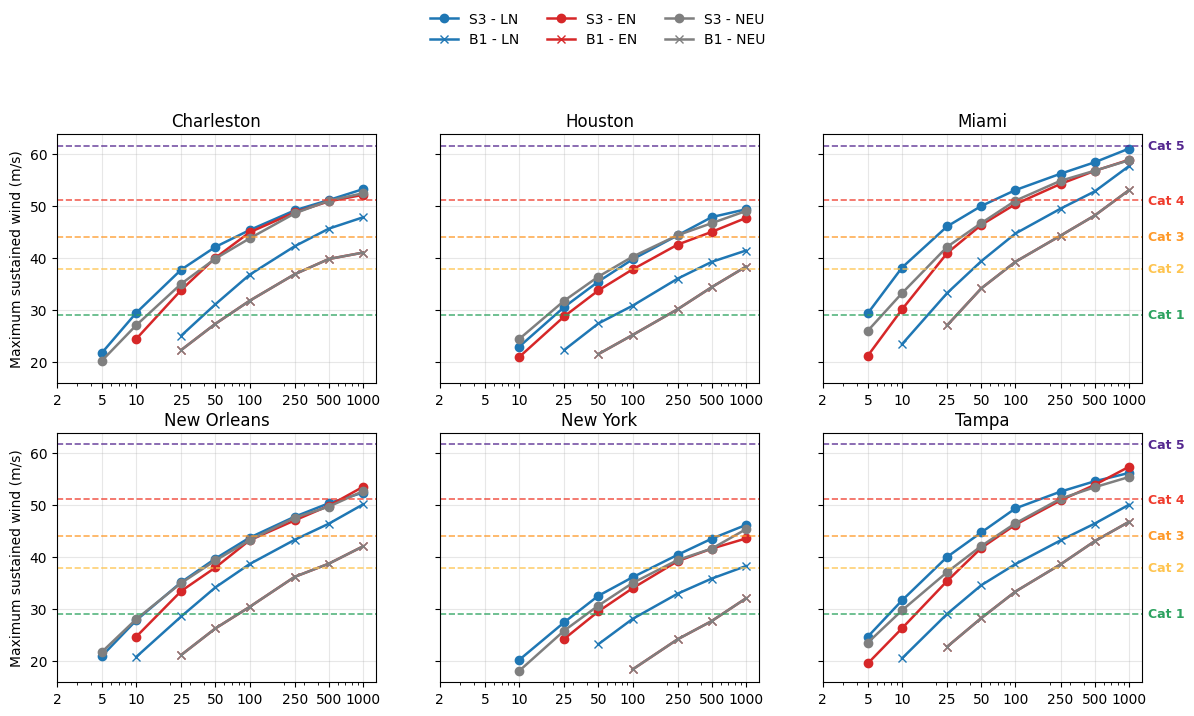

In [34]:
periods = [2, 5, 10, 25, 50, 100, 250, 500, 1000]

CONVERTER_10MIN_1MIN = 0.88

thresholds = [
    ("Cat 1", 33 * CONVERTER_10MIN_1MIN, "#2ca25f"),
    ("Cat 2", 43 * CONVERTER_10MIN_1MIN, "#fec44f"),
    ("Cat 3", 50 * CONVERTER_10MIN_1MIN, "#fe9929"),
    ("Cat 4", 58 * CONVERTER_10MIN_1MIN, "#ef3b2c"),
    ("Cat 5", 70 * CONVERTER_10MIN_1MIN, "#54278f"),
]


dfs = {
    "S3 - LN": (df_la_nina_new.copy(), "tab:blue", "o"),
    "B1 - LN": (df_la_nina.copy(), "tab:blue", "x"),
    "S3 - EN": (df_el_nino_new.copy(), "tab:red", "o"),
    "B1 - EN": (df_el_nino.copy(), "tab:red", "x"),
    "S3 - NEU": (df_neutral_new.copy(), "tab:gray", "o"),
    "B1 - NEU": (df_neutral.copy(), "tab:gray", "x"),
    # "IBTrACS": (df_ibtracs.copy(), "tab:gray"),
}

# Clean all dataframes
for name, (d, color,marker) in dfs.items():
    d["wind_ms"] = pd.to_numeric(d["wind_ms"], errors="coerce")
    d["return_period"] = pd.to_numeric(d["return_period"], errors="coerce")
    dfs[name] = (d, color,marker)

# Union of cities present in any dataframe
cities = sorted(
    set().union(*[set(d["city"].dropna().unique()) for d, _, _ in dfs.values()])
)

# If you want exactly a 3x3 page:
cities = cities[:]

fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True, sharey=True)
axes = axes.ravel()

for i, (ax, city) in enumerate(zip(axes, cities)):
    for label, (d, color,marker) in dfs.items():
        city_data = (
            d.loc[d["city"] == city, ["return_period", "wind_ms"]]
            .dropna()
            .sort_values("return_period")
        )

        if not city_data.empty:
            city_data.plot(
                x="return_period",
                y="wind_ms",
                ax=ax,
                label=label,
                color=color,
                marker=marker,
                linewidth=1.8,
            )

    ax.set_title(city)
    ax.set_xlabel("Return period")
    ax.set_ylabel("Maximum sustained wind (m/s)")
    ax.grid(True, alpha=0.3)
    ax.set_xscale("log")  # optional, but often better for return periods
    
    # Category lines
    for cat_label, y, cat_color in thresholds:
        ax.axhline(y, color=cat_color, linestyle="--", linewidth=1.2, alpha=0.8)

        # show labels only on rightmost column to avoid clutter
        if i % 3 == 2:
            ax.text(
                1.02,
                y,
                cat_label,
                transform=ax.get_yaxis_transform(),  # x in axes coords, y in data coords
                color=cat_color,
                va="center",
                ha="left",
                fontsize=9,
                fontweight="bold",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5),
                clip_on=False,
            )


# hide any unused panels
for ax in axes[len(cities) :]:
    ax.set_visible(False)

# one legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

for ax in axes:
    ax.set_xscale("log")
    ax.set_xticks(periods)
    ax.set_xticklabels([str(p) for p in periods], rotation=0)
    ax.tick_params(axis="x", labelbottom=True)


fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
#fig.suptitle("Wind return levels by city", y=0.95)
#fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# Visualisation Pipeline

In [2]:
from utils.evaluation_pipeline import EvalConfig, run_basin, HAS_CARTOPY

In [3]:
data_dir = "./evaluation_output"
output_dir = "/home/mbaldacchino/data/testing/figures"
basins = ["NA"]
dpi = 300
format = "png" # or pdf
no_cartopy = False


model_map = {
            # "B0": "B0",
            # "B1": "B1",
            # "S1": "S1",
            # "S2": "S2",
            "S3": "S3",  # change to e.g. "S6": "S3" if your hybrid is in the S6 folder
}

cfg = EvalConfig(
    data_dir=data_dir,
    output_dir=output_dir,
    basins=basins,
    dpi=dpi,
    fig_format=format,
    use_cartopy=not no_cartopy,
    model_map=model_map,
)

print("SIENA-IH-STORM Evaluation Pipeline")
print(f"  Data dir:   {cfg.data_dir}")
print(f"  Output dir: {cfg.output_dir}")
print(f"  Basins:     {cfg.basins}")
print(f"  Models:     {cfg.all_model_ids}")
print(f"  Cartopy:    {'yes' if HAS_CARTOPY and cfg.use_cartopy else 'no'}")

for basin in cfg.basins:
    run_basin(cfg, basin)

print("\n✓ Done.")


SIENA-IH-STORM Evaluation Pipeline
  Data dir:   ./evaluation_output
  Output dir: /home/mbaldacchino/data/testing/figures
  Basins:     ['NA']
  Models:     ['S3']
  Cartopy:    yes

  Basin: NA

[1/18] Scorecard heatmap
  Saved: /home/mbaldacchino/data/testing/figures/scorecard_NA.png
[2/18] Summary bar chart
  Saved: /home/mbaldacchino/data/testing/figures/summary_bars_NA.png
[3/18] Genesis density panels


/home/mbaldacchino/miniconda/envs/cat/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mbaldacchino/miniconda/envs/cat/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mbaldacchino/miniconda/envs/cat/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mbaldacchino/miniconda/envs/cat/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mbaldacchino/minic

  Saved: /home/mbaldacchino/data/testing/figures/genesis_density_NA.png


/home/mbaldacchino/miniconda/envs/cat/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mbaldacchino/miniconda/envs/cat/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mbaldacchino/miniconda/envs/cat/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


  Saved: /home/mbaldacchino/data/testing/figures/genesis_density_diff_NA.png
[4/18] Track density panels


...

/home/mbaldacchino/miniconda/envs/cat/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mbaldacchino/miniconda/envs/cat/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


  Saved: /home/mbaldacchino/data/testing/figures/enso_contrast_genesis_density_NA.png
[11/18] Saffir-Simpson category frequencies
  Saved: /home/mbaldacchino/data/testing/figures/ss_categories_NA.png
[12/18] Monthly genesis seasonality
  Saved: /home/mbaldacchino/data/testing/figures/seasonality_NA.png
[13/18] QQ plots (intensity tails)
  Saved: /home/mbaldacchino/data/testing/figures/qq_intensity_NA.png
[14/18] Genesis latitude distribution
  Saved: /home/mbaldacchino/data/testing/figures/genesis_latitude_NA.png
[15/18] Landfall intensity (proxy)
  Saved: /home/mbaldacchino/data/testing/figures/landfall_intensity_NA.png
[16/18] Intensity–duration relationship
  Saved: /home/mbaldacchino/data/testing/figures/intensity_duration_NA.png
[17/18] Return period bootstrap CIs
  Saved: /home/mbaldacchino/data/testing/figures/rp_bootstrap_ci_NA.png
[18/18] ENSO phase ordering diagnostic
  Saved: /home/mbaldacchino/data/testing/figures/enso_ordering_NA.png

Exporting comprehensive metrics CSV
  

/home/mbaldacchino/code/SIENA-IH-STORM/POST_PROCESSING/utils/evaluation_pipeline.py:292: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return (synth_val - obs_val) / obs_val * 100
/home/mbaldacchino/code/SIENA-IH-STORM/POST_PROCESSING/utils/evaluation_pipeline.py:292: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return (synth_val - obs_val) / obs_val * 100


  Exported: /home/mbaldacchino/data/testing/figures/extended_metrics_NA.csv

✓ Done.


/home/mbaldacchino/code/SIENA-IH-STORM/POST_PROCESSING/utils/evaluation_pipeline.py:292: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return (synth_val - obs_val) / obs_val * 100
